Hola &#x1F600;

Soy **Hesus Garcia**, revisor de código, y voy a examinar el proyecto que has desarrollado recientemente. Si encuentro algún error, te lo señalaré para que lo corrijas, ya que mi objetivo es ayudarte a prepararte para un ambiente de trabajo real, donde el líder de tu equipo actuaría de la misma manera. Si no puedes solucionar el problema, te proporcionaré más información en la próxima oportunidad. Cuando encuentres un comentario,  **por favor, no los muevas, no los modifiques ni los borres**. 

Revisaré cuidadosamente todas las implementaciones que has realizado para cumplir con los requisitos y te proporcionaré mis comentarios de la siguiente manera:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

</br>

**¡Empecemos!**  &#x1F680;


# ¿Cuál es un mejor plan?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de los planes genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

Tabla de contenido
- Importación las librerías 
- Carga de los datos
- Preparacion de datos
    - Corregir datos
    - Enrequicer datos
- Condiciones del plan
- Datos de consumos por usuario y mes
- Comportamiento del usuario
- Ingresos por cada plan
- Validación de hipotesis
- Conclusiones



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto. Es bueno incluir una tabla de contenido. 
</div>


## Inicialización

In [6]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar los datos

- En este caso tenemos 5 archivos con la data necesaria para el analisis.

In [7]:
# Carga los archivos de datos en diferentes DataFrames
df_calls = pd.read_csv('datasets/megaline_calls.csv')
df_internet = pd.read_csv('datasets/megaline_internet.csv')
df_message = pd.read_csv('datasets/megaline_messages.csv')
df_plans = pd.read_csv('datasets/megaline_plans.csv')
df_users = pd.read_csv('datasets/megaline_users.csv')


## Preparar los datos

Los datos se encuentran en cinco tablas, primero voy a revisar que columnas contienen y una primera vista de los datos y cantidades.

In [8]:
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [9]:
df_users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN


In [10]:
df_calls

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72
137731,1499_200,1499,2018-10-20,10.89
137732,1499_201,1499,2018-09-21,8.12
137733,1499_202,1499,2018-10-10,0.37


In [11]:
df_internet

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06
104821,1499_216,1499,2018-12-30,304.72
104822,1499_217,1499,2018-09-22,292.75
104823,1499_218,1499,2018-12-07,0.00


In [12]:
df_message

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
...,...,...,...
76046,1497_526,1497,2018-12-24
76047,1497_536,1497,2018-12-24
76048,1497_547,1497,2018-12-31
76049,1497_558,1497,2018-12-24


## Planes

In [13]:
# Imprime la información general/resumen sobre el DataFrame de los planes
print('Tabla planes:')
print(df_plans.info())


Tabla planes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [14]:
# Imprime una muestra de los datos para los planes
print(df_plans.sample(2))

   messages_included  mb_per_month_included  minutes_included  \
1               1000                  30720              3000   
0                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
1               70           7             0.01            0.01  ultimate  
0               20          10             0.03            0.03      surf  



En la tabla planes no veo errores de tipo o valores vacios. Lo que si puedo observar es que tengo el dato de mb por incluidos por mes pero deberia convertirlos a gb ya que es la unidad con la que trabajan normalmente. Ademas veo que se tiene dos planes con diferentes costos y paquetes.

### Corregir los datos

No encontre datos a primera vista para corregir en la tabla.

### Enriquecer los datos

- Agregare una columna a la tabla planes con la conversion de mb a gb.

In [15]:
df_plans['gb_per_month_included']=(df_plans['mb_per_month_included'] / 1000)
df_plans.sample(2)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.36
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.72


## Usuarios

In [16]:
# Información general/resumen sobre el DataFrame de los usuarios
print('Tabla usuarios:')
print(df_users.info())


Tabla usuarios:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [17]:
# Muestra de los datos para los usuarios
print(df_users.sample(4))

     user_id first_name last_name  age  \
463     1463    Dinorah   Simmons   30   
332     1332      Lucas  Saunders   37   
389     1389    Earleen     Glass   18   
64      1064    Gerardo    Ashley   46   

                                              city    reg_date      plan  \
463          Atlanta-Sandy Springs-Roswell, GA MSA  2018-11-27  ultimate   
332          Atlanta-Sandy Springs-Roswell, GA MSA  2018-03-12      surf   
389  Miami-Fort Lauderdale-West Palm Beach, FL MSA  2018-05-06  ultimate   
64       New York-Newark-Jersey City, NY-NJ-PA MSA  2018-06-03      surf   

    churn_date  
463        NaN  
332        NaN  
389        NaN  
64         NaN  


En la tabla hay valores ausentes en la columna churn_date, asumire que los valores ausentes son servicios activos al momento del reporte. Y las columnas de fecha de registro y fecha de churn tiene un formato incorrecto. 



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correctas tus afirmaciones sobre churn_data
</div>


### Corregir datos

- Corregire el tipo de formato de las columnas fecha de registro y la fecha en que el usuario dejó de usar el servicio, cambiare al tipo de formato datetime.

In [18]:
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')

### Enriquecer datos

- Agregare dos columnas con los meses correspondientes a reg_month y churn_date, para utilizar estos datos mas adelante.

In [19]:
df_users['reg_month'] = df_users['reg_date'].dt.month
df_users['churn_month'] = df_users['churn_date'].dt.month

## Llamadas

In [20]:
# Imprime la información/resumen general sobre el DataFrame de las llamadas
print('Tabla calls:')
print(df_calls.info())


Tabla calls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [21]:
# Imprime una muestra de datos para llamadas
print(df_calls.sample(3))

             id  user_id   call_date  duration
105966  1374_62     1374  2018-11-02      9.04
43033   1157_62     1157  2018-07-25      5.68
1417    1008_58     1008  2018-12-17     10.77


El problema que encuentro es que el tipo de call_date es de tipo object y no date. La duración esta en minutos pero es de tipo float es decir tiene decimales y sabemos que Megaline redondea los segundos a minutos y cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto. 

### Corregir datos

Corregi el formato de Id, y call_date. Y redondee hacia arriba los minutos de duration.

In [22]:
df_calls['id'] = df_calls['id'].astype(int)
df_calls['call_date'] = pd.to_datetime(df_calls ['call_date'],format ='%Y/%m/%d')
df_calls['duration'] = np.ceil(df_calls['duration'])



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto
</div>


### Enriquecer datos

Agregare el mes en que se realizo la llamada como una columna a la tabla.

In [23]:
df_calls['call_month'] = df_calls['call_date'].dt.month

In [24]:
#De acuerdo a la descripcion: "En la columna duration de df_calls hay valores 0 que podrian ser llamadas perdidas"
# Voy a calcular a cuanto ascienden estos datos.

cuenta_duracion=df_calls['duration'].value_counts().sum()
duracion_cero = (df_calls['duration'] == 0).value_counts()[True]
print(duracion_cero/cuenta_duracion*100)

19.482339274694162


- A pesar de ser casi el 20%, los valores cero no nos sirven para hallar los ingresos por cliente por ello quitare estos datos.

In [25]:
#Tabla de de llamadas sin valores o en duración de llamada
df_calls_limpio= df_calls.query('duration>0')

In [26]:
print(df_calls_limpio.head(3))

        id  user_id  call_date  duration  call_month
0   100093     1000 2018-12-27       9.0          12
1  1000145     1000 2018-12-27      14.0          12
2  1000247     1000 2018-12-27      15.0          12




<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto
</div>


## Mensajes

In [27]:
# Información/resumen general sobre el DataFrame de los mensajes
print('Tabla mensajes:')
print(df_message.info())


Tabla mensajes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [28]:
# Muestra de datos para los mensajes
print(df_message.sample(3))

             id  user_id message_date
65804   1425_21     1425   2018-10-24
68030  1439_424     1439   2018-09-02
30783  1193_550     1193   2018-07-21


- Problema: El tipo de message_date es object y no date. No veo valores ausentes.

### Corregir datos

Cambie el tipo de datos de la columna Id y message_date.

In [29]:
df_message['id'] = df_message['id'].astype(int)
df_message['message_date'] = pd.to_datetime(df_message['message_date'], format ='%Y-%m-%d')

### Enriquecer datos

Agregare el mes en el que se mando el mensaje en una nueva columna.

In [30]:
df_message['message_month'] = df_message['message_date'].dt.month



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto
</div>


## Internet

In [31]:
# Información/resumen general sobre el DataFrame de los mensajes
print('Tabla internet:')
print(df_internet.info())


Tabla internet:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [32]:
# Muestra de datos para el tráfico de internet
print(df_internet.sample(3))

             id  user_id session_date  mb_used
57233  1258_227     1258   2018-11-25     0.00
61296   1278_73     1278   2018-12-16   131.62
9059   1046_344     1046   2018-08-30   314.80


No veo valores vacios, el tipo de datos en session_date no es de tipo date. Ademas el id es de tipo object. 

### Corregir datos

- Cambiare el tipo de dato de id y session_date.

In [33]:
df_internet['id'] = df_internet['id'].astype(int)
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format ='%Y-%m-%d')



<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
En las instrucciones se menciona lo siguiente.Nota: Megaline redondea los segundos a minutos y los megabytes a gigabytes.
</div>


### Enriquecer datos

Agregare una columna con el mes de la sesion.

In [34]:
df_internet['session_month'] = df_internet['session_date'].dt.month

## Estudiar las condiciones del plan

Tenemos dos planes, con diferentes precios y condiciones. Taambien ya tenemmos los GB incluidos por mes.

In [35]:
# Imprime las condiciones del plan y asegúrate de que te resulten claros
print(df_plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                  15.36  
1                  30.72  


## Agregar datos por usuario

Calculare el número de llamadas, la cantidad de minutos, el número de mensajes y el volumen de trafico de internet.Y las agrupare en un tabla por usuario y mes de consumo.

In [36]:
# Calculo del número de llamadas hechas por cada usuario por mes. 
datos_agrupado   = df_calls_limpio.groupby(['user_id', 'call_month'])[['id']].count()
datos_agrupado.columns = ['calls_count']

# Calculo de la cantidad de minutos que usó cada usuario por mes. 
datos_agrupado['minute_count'] = df_calls_limpio.groupby(['user_id', 'call_month'])[['duration']].sum()

# Calculo  del número de mensajes enviados por cada usuario por mes. 
datos_agrupado['message_count'] = df_message.groupby(['user_id', 'message_month'])[['id']].count()

# Calculo  del volumen del trafico de internet usado por cada usuario por mes y el cambio 
datos_agrupado['mb_count'] = df_internet.groupby(['user_id', 'session_month'])[['mb_used']].sum()
datos_agrupado['gb_count'] = np.ceil(datos_agrupado['mb_count']/1000)
datos_agrupado = datos_agrupado.reset_index()

datos_agrupado.head()

,user_id,call_month,calls_count,minute_count,message_count,mb_count,gb_count
0,1000,12,16,124.0,11.0,1901.47,2.0
1,1001,8,22,182.0,30.0,6919.15,7.0
2,1001,9,38,315.0,44.0,13314.82,14.0
3,1001,10,47,393.0,53.0,22330.49,23.0
4,1001,11,49,426.0,36.0,18504.30,19.0




<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Recuerda que la conversión es 1 Gb = 1024 Mb
</div>


In [37]:
#Tabla del consumo de llamadas, minutos, mensajes e internet de los usuario por mes.
print(datos_agrupado.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        2256 non-null   int64  
 1   call_month     2256 non-null   int64  
 2   calls_count    2256 non-null   int64  
 3   minute_count   2256 non-null   float64
 4   message_count  1772 non-null   float64
 5   mb_count       2241 non-null   float64
 6   gb_count       2241 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 123.5 KB
None


- Ahora que tengo los consumos por usuario en la tabla datos_agrupado los unire con la tabla de usuarios que contiene los datos del plan y otros datos de los usuarios. 

In [38]:
#union de tabla users y datos agrupados a partir del user id.
users_used = pd.merge( df_users, datos_agrupado , on = ['user_id'],how='outer')
#cambiar nombre de la  columna call_month por Month_used. Para entender mejor la tabla
users_used = users_used.rename(columns={'call_month': 'month_used'})
#Muestra de la tabla unida
users_used.head(2)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month,churn_month,month_used,calls_count,minute_count,message_count,mb_count,gb_count
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,12,NaN,12.0,16.0,124.0,11.0,1901.47,2.0
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,NaN,8.0,22.0,182.0,30.0,6919.15,7.0


Para poder calcular los ingresos unire la tabla user_used calculado antes con la tabla plan usando la funcion merge.

In [39]:
#Uni la tabla de consumo de usuarios con la tabla de planes para poder calcular el ingreso total
users_used_plan = pd.merge(users_used, df_plans, left_on='plan', right_on='plan_name', how='inner')
users_used_plan.sample(2)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month,churn_month,...,gb_count,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
2111,1434,Kai,Barr,18,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-03-06,surf,NaT,3,NaN,...,16.0,50,15360,500,20,10,0.03,0.03,surf,15.36
1580,1268,Britni,Bowers,33,"Fresno, CA MSA",2018-01-13,surf,NaT,1,NaN,...,35.0,50,15360,500,20,10,0.03,0.03,surf,15.36




<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Evalúa las consideraciones entre utilizar un inner join en oposición a un outer join. Pudo haber pérdida de datos ? 
</div>


In [40]:
#Funcion para hallar los ingresos adicionales por internet, llamada y mensaje
def ingresos_extra_usuario(usado, incluido, usd_precio, monthly_pay):
    if (usado - incluido) > 0:
        return (usado - incluido) * usd_precio + monthly_pay
    else:
        return 0
    
    

In [41]:
#Agregar columnas de ingresos extras por internet, mensajes y minutos usando la funcion de ingresos extra usuario.
users_used_plan['ingresos_gb'] = users_used_plan.apply(lambda row: ingresos_extra_usuario(row['gb_count'], row['gb_per_month_included'], row['usd_per_gb'], row['usd_monthly_pay']), axis=1)
users_used_plan['ingresos_minutos'] = users_used_plan.apply(lambda row: ingresos_extra_usuario(row['minute_count'], row['minutes_included'], row['usd_per_minute'], row['usd_monthly_pay']), axis=1)
users_used_plan['ingresos_mensaje'] = users_used_plan.apply(lambda row: ingresos_extra_usuario(row['message_count'], row['messages_included'], row['usd_per_message'], row['usd_monthly_pay']), axis=1)


In [42]:
#Funcion que calcula los ingresos totales por usuario
def ingresos_total(ingreso_gb, ingreso_minute, ingreso_mensaje, monthly_pay):
        total=ingreso_gb+ingreso_minute+ingreso_mensaje+monthly_pay
        return total

In [43]:
# Agregue la columna de ingreso total (ingreso mensual para cada usuario inclyendo el pago mensual fijo y los extras).
users_used_plan['ingresos_total'] = users_used_plan.apply(lambda row: ingresos_total(row['ingresos_gb'], row['ingresos_minutos'], row['ingresos_mensaje'], row['usd_monthly_pay']), axis=1)


In [44]:
#Comprobando que funciono con la muestra de la tabla con los ingresos total por usuario y por mes
users_used_plan.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month,churn_month,...,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,ingresos_gb,ingresos_minutos,ingresos_mensaje,ingresos_total
740,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaT,7,NaN,...,20,10,0.03,0.03,surf,15.36,166.4,23.51,0.00,209.91
1416,1217,Ned,Thomas,69,"Dayton-Kettering, OH MSA",2018-06-04,surf,NaT,6,NaN,...,20,10,0.03,0.03,surf,15.36,56.4,22.31,0.00,98.71
2140,1444,Glinda,Dickerson,70,"New Haven-Milford, CT MSA",2018-06-20,surf,NaT,6,NaN,...,20,10,0.03,0.03,surf,15.36,36.4,0.00,20.09,76.49
1591,1277,Andrew,Faulkner,25,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-02,surf,NaT,2,NaN,...,20,10,0.03,0.03,surf,15.36,106.4,28.73,0.00,155.13
2230,1489,Londa,Jenkins,72,"Detroit-Warren-Dearborn, MI MSA",2018-05-24,surf,NaT,5,NaN,...,20,10,0.03,0.03,surf,15.36,56.4,0.00,21.23,97.63


In [45]:
users_used_plan.query("user_id == 1001")

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month,churn_month,...,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,ingresos_gb,ingresos_minutos,ingresos_mensaje,ingresos_total
718,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,NaN,...,20,10,0.03,0.03,surf,15.36,0.0,0.0,0.00,20.00
719,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,NaN,...,20,10,0.03,0.03,surf,15.36,0.0,0.0,0.00,20.00
720,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,NaN,...,20,10,0.03,0.03,surf,15.36,96.4,0.0,20.09,136.49
721,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,NaN,...,20,10,0.03,0.03,surf,15.36,56.4,0.0,0.00,76.40
722,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,NaN,...,20,10,0.03,0.03,surf,15.36,66.4,0.0,0.00,86.40


## Estudia el comportamiento del usuario

### Llamadas

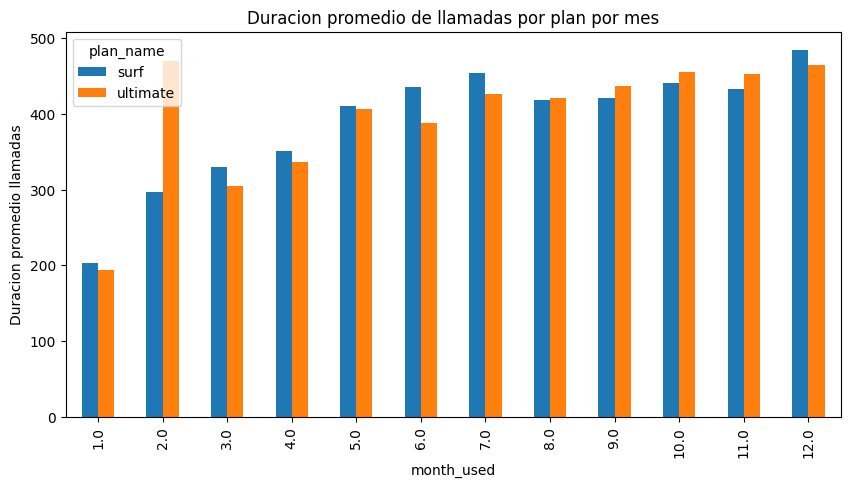

In [46]:
# Compara la duración promedio de llamadas por cada plan por cada mes. Dibuja una gráfica de barras para visualizarlo.
df_promedio_llamadas = users_used_plan.groupby(['plan_name','month_used'])['minute_count'].mean().reset_index()
df_promedio_llamadas.pivot(index='month_used', columns='plan_name', values = 'minute_count').plot(kind='bar',figsize=(10,5))

plt.xlabel('month_used')
plt.ylabel('Duracion promedio llamadas')
plt.title('Duracion promedio de llamadas por plan por mes')

plt.show()




<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto
</div>


In [47]:
pivot1=df_promedio_llamadas.pivot(index='month_used', columns='plan_name', values = 'minute_count')
pivot1

plan_name,surf,ultimate
month_used,,
1.0,203.000000,193.500000
2.0,297.000000,470.333333
3.0,330.000000,304.250000
4.0,351.540000,336.857143
5.0,410.240000,406.241379
6.0,435.791667,387.444444
7.0,453.733333,427.067797
8.0,417.849057,421.436620
9.0,420.732984,437.511628


En algunos meses, la diferencia entre la duración promedio de llamadas en los dos planes es más pronunciada. Por ejemplo, en febrero, la duración promedio de las llamadas en el plan Ultimate es mucho mayor que en el plan Surf.

En otros meses, como agosto y septiembre, la duración promedio de las llamadas es similar en ambos planes.

En general, la duración promedio de las llamadas parece aumentar ligeramente a medida que avanza el año, pero esta tendencia no es muy pronunciada.

Text(0.5, 0, 'Minutos por mes')

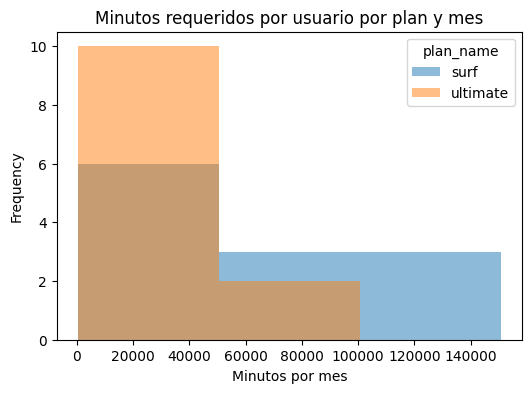

In [48]:
# Compara el número de minutos que los usuarios de cada plan requieren cada mes. Traza un histograma.
minutos_mes = users_used_plan.groupby(['plan_name','month_used'])['minute_count'].sum().reset_index()
minutos_mes.pivot(index='month_used',columns= 'plan_name',values='minute_count').plot(kind='hist', alpha=0.5,bins=(3), figsize=(6,4))

plt.title('Minutos requeridos por usuario por plan y mes')
plt.xlabel('Minutos por mes')

In [49]:
n_bins = int((max(minutos_mes['minute_count']) - min(minutos_mes['minute_count'])) / (3.5 * np.std(minutos_mes['minute_count']) * len(minutos_mes['minute_count'])**(-1/3)))

print("Número de bins según la regla de Scott:", n_bins)

Número de bins según la regla de Scott: 3


In [50]:
tabla2=minutos_mes.pivot(index='month_used',columns= 'plan_name',values='minute_count')
print(tabla2)

plan_name       surf  ultimate
month_used                    
1.0            406.0     774.0
2.0           2673.0    2822.0
3.0           7590.0    3651.0
4.0          17577.0    7074.0
5.0          30768.0   11781.0
6.0          41836.0   17435.0
7.0          54448.0   25197.0
8.0          66438.0   29922.0
9.0          80360.0   37626.0
10.0        101846.0   47778.0
11.0        119801.0   56540.0
12.0        150680.0   69324.0


En este histograma puedo observar que el plan ultimate los  10 primeros meses se consumio menos de 50000 minutos por mes aprox  a diferencia del plan surf que en 6 meses se consumio hasta 50000 minutos cantidad por mes aprox. Los dos ultimos meses aumento la cantidad de minutos requeridos hasta 69324. Por otro lado en los 3 meses siguientes en el plan surf se requirio entre 50000 y 100000 minutos superando al plan ultimate. Finalmente los 3 ultimos meses el plan surf requirio entre 100000 y 150000 minutos aprox.

In [51]:
# Calcula la media y la varianza de la duración mensual de llamadas.
ultimate_minutos = minutos_mes[minutos_mes['plan_name'] == 'ultimate']['minute_count']
media=ultimate_minutos.mean().round()
varianza = np.var(ultimate_minutos).round()
std=np.std(ultimate_minutos).round()
print('Media=',media)
print('Varianza=',varianza)
print('Desviacion estandar=', std)
print('Los usuarios del plan ultimate requieren', media, '+/- ', std, 'minutos por mes.')

Media= 25827.0
Varianza= 478462892.0
Desviacion estandar= 21874.0
Los usuarios del plan ultimate requieren 25827.0 +/-  21874.0 minutos por mes.


In [52]:
surf_minutos = minutos_mes[minutos_mes['plan_name'] == 'surf']['minute_count']
media=surf_minutos.mean().round()
varianza = np.var(surf_minutos).round()
std=np.std(surf_minutos).round()
print('Media=',media)
print('Varianza=',varianza)
print('Desviacion estandar=', std)
print('Los usuarios del plan surf requieren', media, '+/- ', std, 'minutos por mes.')

Media= 56202.0
Varianza= 2202716345.0
Desviacion estandar= 46933.0
Los usuarios del plan surf requieren 56202.0 +/-  46933.0 minutos por mes.


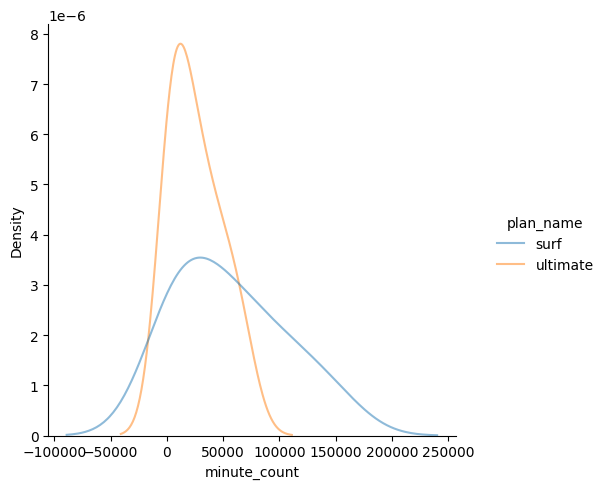

In [53]:
sns.displot(x='minute_count',data=minutos_mes, hue='plan_name', kind='kde', alpha =0.5)

La desviación estándar de la duración de las llamadas en minutos por mes del plan Surf es 46933 lo que indica que la duración de las llamadas en minutos por mes del plan Surf se distribuye ampliamente en torno a la media aun mas que el plan ultimate.
Con el grafico podemos corroborar que los datos se distribuyen mas ampliamente en el caso de Surf que en el de Ultimate. y tambien observamos que la media de Surf esta desplazado mas a la derecha que el de Ultimate.  

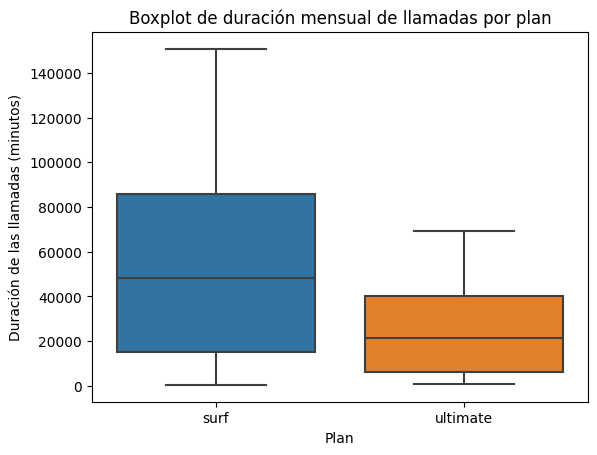

In [54]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas.

sns.boxplot(data=minutos_mes, x='plan_name', y='minute_count')
plt.title('Boxplot de duración mensual de llamadas por plan')
plt.xlabel('Plan')
plt.ylabel('Duración de las llamadas (minutos)')

plt.show()

- En general, la duración promedio de las llamadas es mayor en el plan Surf que en el plan Ultimate. Este patrón se mantiene en la mayoría de los meses.
- "Surf" tuvo un uso más alto de minutos en promedio en comparación con el plan "Ultimate"
- En el rango de un año el crecimiento de minutos utilizados en el plan "Surf" ha sido más rápido que en el plan "Ultimate" en el transcurso del año.
- La desviación estándar del plan Surf es mayor que la del plan Ultimate, lo que sugiere que la duración de las llamadas en minutos por mes del plan Surf se distribuye más ampliamente que la del plan Ultimate.
- La distribución de la duracion de las llamadas por mes del plan Surf tiene un rango de datos mas amplio que el plan ultimate. Tambien se observa que la mediana de Surf es mayor que el plan de Ultimate lo que indica un IQR mayor. 

### Mensajes

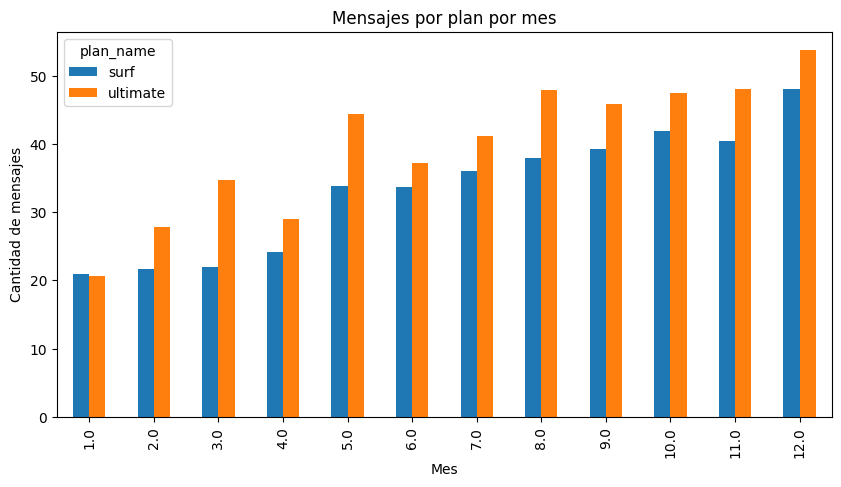

In [55]:
# Comparación del número de mensajes que tienden a enviar cada mes los usuarios en promedio por cada plan

num_message = users_used_plan.groupby(['month_used','plan_name'])['message_count'].mean().reset_index()
num_message.pivot(index='month_used', columns='plan_name', values = 'message_count').plot(kind='bar',figsize=(10,5))

plt.xlabel('Mes')
plt.ylabel('Cantidad de mensajes')
plt.title('Mensajes por plan por mes')
plt.figsize=(15,9)
plt.show()


En general, la cantidad promedio de mensajes enviados es mayor en el plan Ultimate que en el plan Surf. Este patrón se mantiene en la mayoría de los meses.



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto
</div>


Text(0.5, 0, 'Distribución Mensajes')

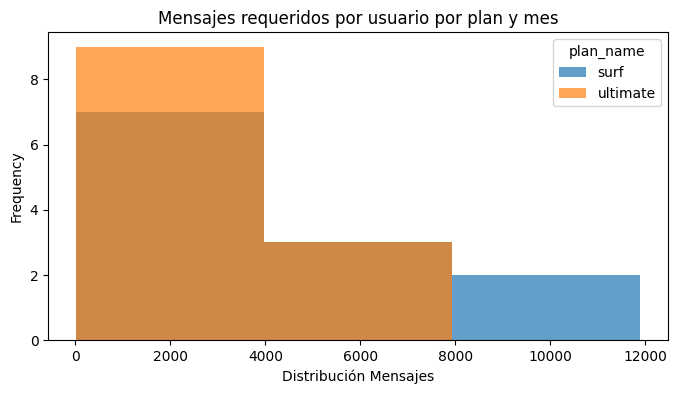

In [56]:
# Compara el número de mensajes que los usuarios de cada plan requieren cada mes.
mensajes_mes = users_used_plan.groupby(['month_used', 'plan_name'])['message_count'].sum().reset_index()

mensajes_mes.pivot(index='month_used',columns= 'plan_name',values='message_count').plot(kind='hist', alpha=0.7, bins=3,figsize=(8,4))

plt.title('Mensajes requeridos por usuario por plan y mes')
plt.xlabel('Distribución Mensajes')

In [57]:
tabla3=mensajes_mes.pivot(index='month_used',columns= 'plan_name',values='message_count')
tabla3

plan_name,surf,ultimate
month_used,,
1.0,21.0,62.0
2.0,108.0,139.0
3.0,351.0,243.0
4.0,870.0,463.0
5.0,1829.0,931.0
6.0,2427.0,1374.0
7.0,3243.0,1937.0
8.0,4588.0,2732.0
9.0,5802.0,3259.0


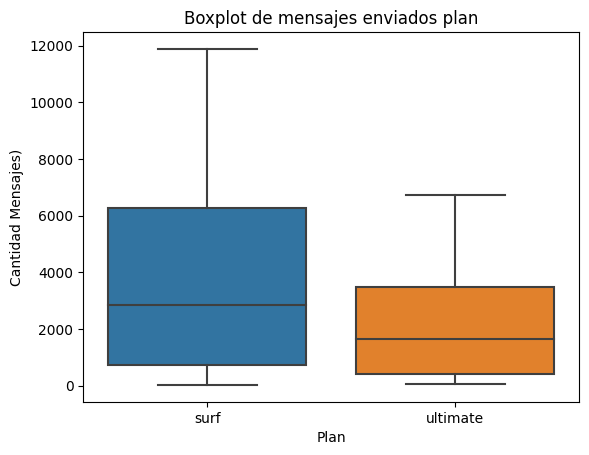

In [58]:
# Traza un diagrama de caja para visualizar la distribución de mensajes.

sns.boxplot(data=mensajes_mes, x='plan_name', y='message_count')
plt.title('Boxplot de mensajes enviados plan')
plt.xlabel('Plan')
plt.ylabel('Cantidad Mensajes)')

plt.show()

In [59]:
surf_mensaje = mensajes_mes[mensajes_mes['plan_name'] == 'surf']['message_count']
media_mensaje_surf=surf_mensaje.mean()
varianza_mensaje_surf= np.var(surf_mensaje)
std_mensaje_surf=np.std(surf_mensaje)
print('Plan Surf')
print('Media=',media_mensaje_surf)
print('Varianza=',varianza_mensaje_surf)
print('Desviacion estandar=',std_mensaje_surf)



Plan Surf
Media= 3978.0833333333335
Varianza= 13782650.409722222
Desviacion estandar= 3712.499213430519


In [60]:
#Media, varianza y desviacion estandar delos ingresos totales por mes del plan Ultimate.
ultimate_mensaje = mensajes_mes[mensajes_mes['plan_name'] == 'ultimate']['message_count']

media_mensaje_ult=ultimate_mensaje.mean()
varianza_mensaje_ult = np.var(ultimate_mensaje)
std_ingreso_ult = np.std(ultimate_mensaje)
print('Plan Ultimate')
print('Media=',media_mensaje_ult)
print('Varianza=',varianza_mensaje_ult)
print('Desviacion estandar=',std_ingreso_ult)



Plan Ultimate
Media= 2241.4166666666665
Varianza= 4234656.243055556
Desviacion estandar= 2057.82804020539


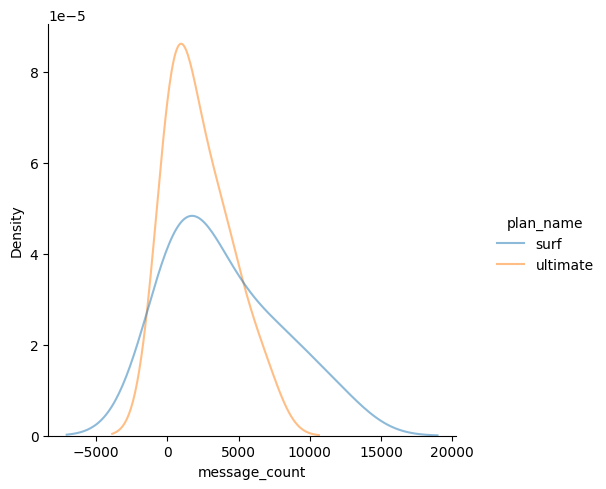

In [61]:
sns.displot(x='message_count',data=mensajes_mes, hue='plan_name', kind='kde', alpha =0.5)

 - En general, el  promedio de envio de mensajes es mayor en el plan Ultimate que en el plan Surf. Este patrón se mantiene en la mayoría de los meses.
- En el rango de un año el crecimiento de los mensajes utilizados en el plan "Surf" ha sido más rápido que en el plan "Ultimate" en el transcurso del año.
- La desviación estándar del plan Surf es mayor que la del plan Ultimate, lo que sugiere que la duración de las llamadas en minutos por mes del plan Surf se distribuye más ampliamente que la del plan Ultimate.
- La distribución de la duracion de las llamadas por mes del plan Surf tiene un rango de datos mas amplio que el plan ultimate. Tambien se observa que la mediana de Surf es mayor que el plan de Ultimate lo que indica un IQR mayor. 

### Internet

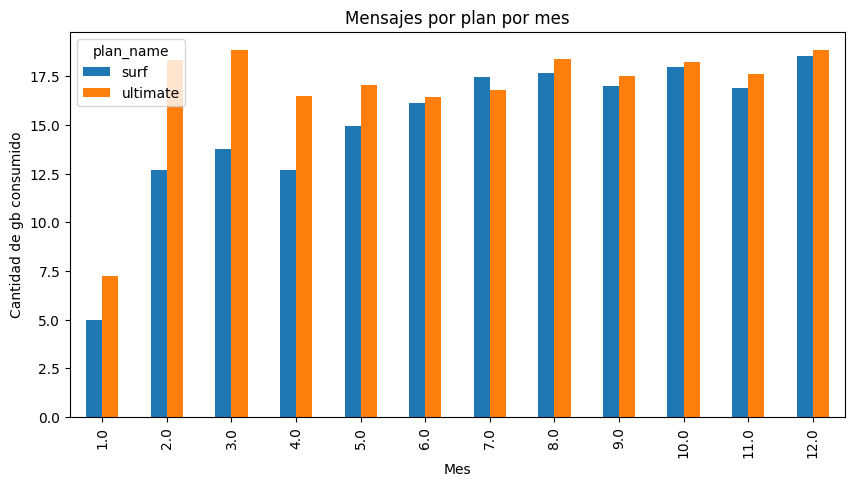

In [62]:
# Compara la cantidad de tráfico de internet consumido por usuarios por plan
num_internet = users_used_plan.groupby(['plan_name','month_used'])['gb_count'].mean().reset_index()
num_internet.pivot(index='month_used', columns='plan_name', values = 'gb_count').plot(kind='bar',figsize=(10,5))


plt.xlabel('Mes')
plt.ylabel('Cantidad de gb consumido')
plt.title('Mensajes por plan por mes')
plt.figsize=(15,9)
plt.show()



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto.
</div>


Text(0.5, 0, 'Distribución gb')

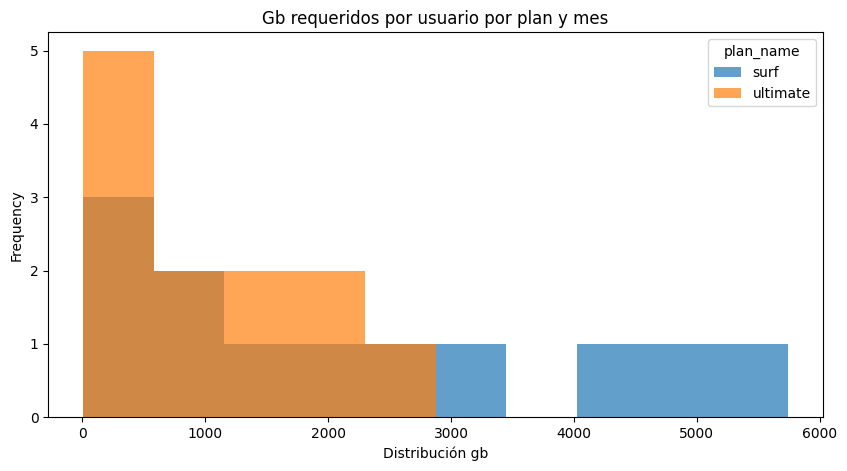

In [63]:
internet_mes = users_used_plan.groupby(['month_used', 'plan_name'])['gb_count'].sum().reset_index()

internet_mes.pivot(index='month_used',columns= 'plan_name',values='gb_count').plot(kind='hist', alpha=0.7, figsize=(10,5))

plt.title('Gb requeridos por usuario por plan y mes')
plt.xlabel('Distribución gb')

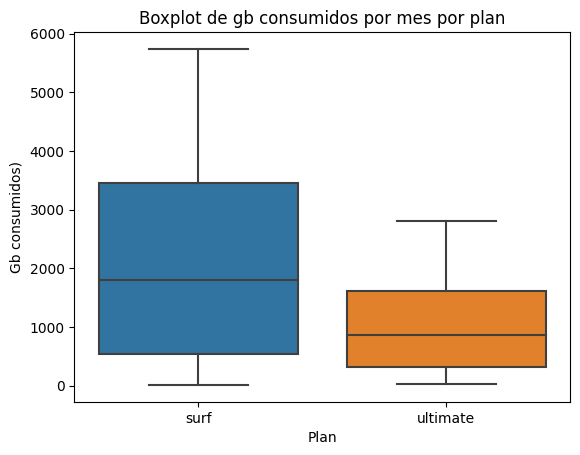

In [64]:
# Traza un diagrama de caja para visualizar la distribución de la gb mensual.

sns.boxplot(data=internet_mes, x='plan_name', y='gb_count')
plt.title('Boxplot de gb consumidos por mes por plan')
plt.xlabel('Plan')
plt.ylabel('Gb consumidos)')

plt.show()

In [65]:
surf_internet = internet_mes[internet_mes['plan_name'] == 'surf']['gb_count']
media_gb_surf=surf_internet.mean()
varianza_gb_surf= np.var(surf_internet)
std_gb_surf=np.std(surf_internet)
print('Plan Surf')
print('Media=',media_gb_surf)
print('Varianza=',varianza_gb_surf)
print('Desviacion estandar=',std_gb_surf)

Plan Surf
Media= 2186.4166666666665
Varianza= 3367253.243055556
Desviacion estandar= 1835.0076956393277


In [66]:
ultimate_internet = internet_mes[internet_mes['plan_name'] == 'ultimate']['gb_count']
media_gb_ult=ultimate_internet.mean()
varianza_gb_ult= np.var(ultimate_internet)
std_gb_ult=np.std(ultimate_internet)
print('Plan Ultimate')
print('Media=',media_gb_ult)
print('Varianza=',varianza_gb_ult)
print('Desviacion estandar=',std_gb_ult)

Plan Ultimate
Media= 1056.5833333333333
Varianza= 746314.5763888889
Desviacion estandar= 863.8950031044797


In [67]:
tabl3=num_internet.pivot(index='month_used', columns='plan_name', values = 'gb_count')


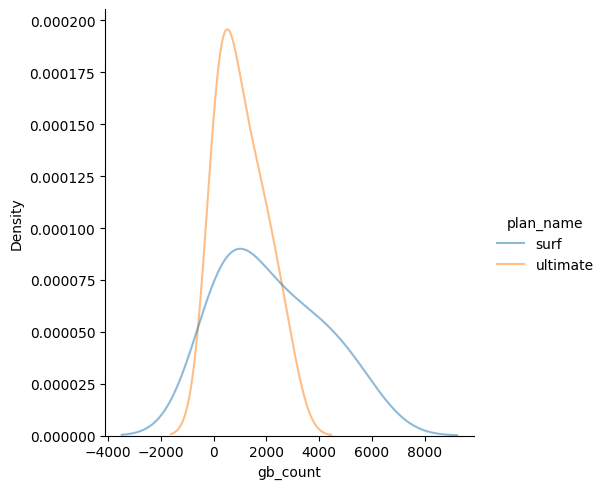

In [68]:
#grafico que muestra la media y desviacin estandar por plan
sns.displot(x='gb_count',data=internet_mes, hue='plan_name', kind='kde', alpha =0.5)

 
-La varianza indica que el consumo de GB mensual varía mucho entre los usuarios, pero en promedio, los usuarios consumen alrededor de 1621.5 GB cada mes.
-La media en entre planes es diferente y el plan Surf se muestra mas amplia que el plan ultimate,

## Ingreso

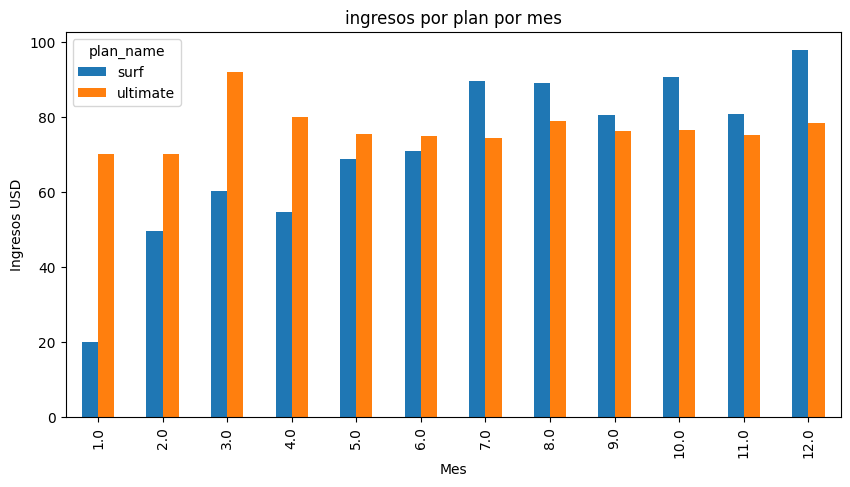

In [69]:
# Comparar el ingreso promedio mensual por plan.

ingresos_medio = users_used_plan.groupby(['plan_name','month_used'])['ingresos_total'].mean().reset_index()
ingresos_medio.pivot(index='month_used', columns='plan_name', values = 'ingresos_total').plot(kind='bar', figsize=(10,5))

plt.xlabel('Mes')
plt.ylabel('Ingresos USD')
plt.title('ingresos por plan por mes')
plt.figsize=(10,5)
plt.show()

<Axes: ylabel='Frequency'>

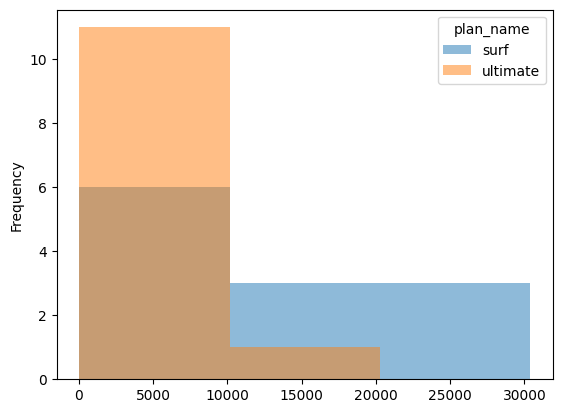

In [70]:
#Comparar los ingresos por plan y por mes
ingreso_mes_plan=users_used_plan.groupby(['plan_name','month_used'])['ingresos_total'].sum().reset_index()
ingreso_mes_plan.pivot(index='month_used', columns='plan_name', values = 'ingresos_total').plot(kind='hist', alpha=0.5, bins=3)

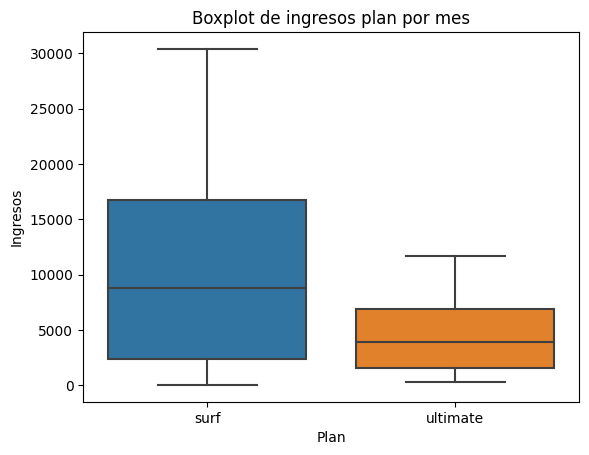

In [71]:
#Distibución de ingresos
sns.boxplot(data=ingreso_mes_plan, x='plan_name', y='ingresos_total')
plt.title('Boxplot de ingresos plan por mes')
plt.xlabel('Plan')
plt.ylabel('Ingresos')

plt.show()

<Axes: xlabel='month_used'>

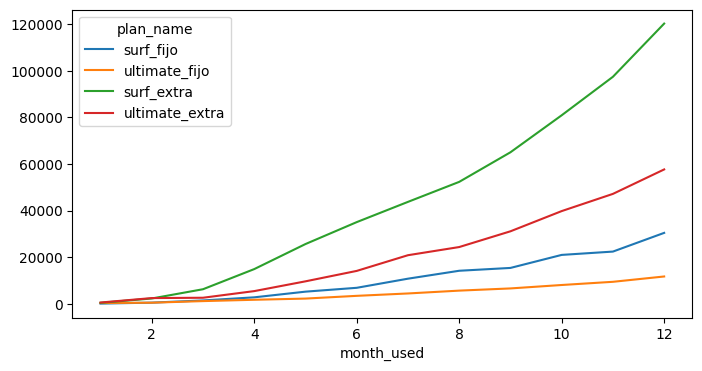

In [72]:
# Quiero comparar el origen de los ingresos, filtrare los usuarios que hicieron solo pagos fijos.
#Luego creare una tabla que tenga los ingresos por pagos extras y pagos fijos. Mostrare los resultados en un grafico de lineas
df_fijo= users_used_plan.query('ingresos_gb == 0 and ingresos_minutos == 0 and ingresos_mensaje==0')
ingresos_fijo = users_used_plan.groupby(['plan_name','month_used'])['ingresos_total'].sum().reset_index()

suma_fijo=ingresos_fijo.pivot(index='month_used', columns='plan_name', values = 'ingresos_total')
comparar= pd.merge(suma_fijo, tabla2, on='month_used', how='inner')
comparar['surf_extra']= comparar['surf_y']-comparar['surf_x']
comparar['ultimate_extra']= comparar['ultimate_y']-comparar['ultimate_x']
fijo_extra = comparar.drop(['surf_y', 'ultimate_y'], axis=1)
fijo_extra.rename(columns={"surf_x": "surf_fijo"}, inplace=True)
fijo_extra.rename(columns={"ultimate_x": "ultimate_fijo"}, inplace=True)


fijo_extra.plot(kind='line',figsize=(8,4))


In [73]:
tabla6 = ingreso_mes_plan.pivot(index='month_used', columns='plan_name', values = 'ingresos_total')

# Distribución de los ingresos por plan.
print(tabla6.sum())
# Distribución de los ingresos por plan y segun el tipo de ingreso (fijo y extra)
fijo_extra.sum().sort_values(ascending=False)

plan_name
surf        130501.52
ultimate     54660.20
dtype: float64


plan_name
surf_extra        543921.48
ultimate_extra    255263.80
surf_fijo         130501.52
ultimate_fijo      54660.20
dtype: float64

In [74]:
#Media, varianza y desviacion estandar delos ingresos totales por mes del plan Surf
surf_ingreso = ingreso_mes_plan[ingreso_mes_plan['plan_name'] == 'surf']['ingresos_total']
media_ingreso_surf=surf_ingreso.mean()
varianza_ingreso_surf= np.var(surf_ingreso)
std_ingreso_surf=np.std(surf_ingreso)
print('Plan Surf')
print('Media=',media_ingreso_surf)
print('Varianza=',varianza_ingreso_surf)
print('Desviacion estandar=',std_ingreso_surf)

Plan Surf
Media= 10875.126666666669
Varianza= 89770830.98702222
Desviacion estandar= 9474.747014407414


In [75]:
#Media, varianza y desviacion estandar delos ingresos totales por mes del plan Ultimate.
ultimate_ingreso = ingreso_mes_plan[ingreso_mes_plan['plan_name'] == 'ultimate']['ingresos_total']
media_ingreso_ult=ultimate_ingreso.mean()
varianza_ingreso_ult = np.var(ultimate_ingreso)
std_ingreso_ult = np.std(ultimate_ingreso)
print('Plan Ultimate')
print('Media=',media_ingreso_ult)
print('Varianza=',varianza_ingreso_ult)
print('Desviacion estandar=',std_ingreso_ult)

Plan Ultimate
Media= 4555.016666666666
Varianza= 12816626.976922221
Desviacion estandar= 3580.0317005471084


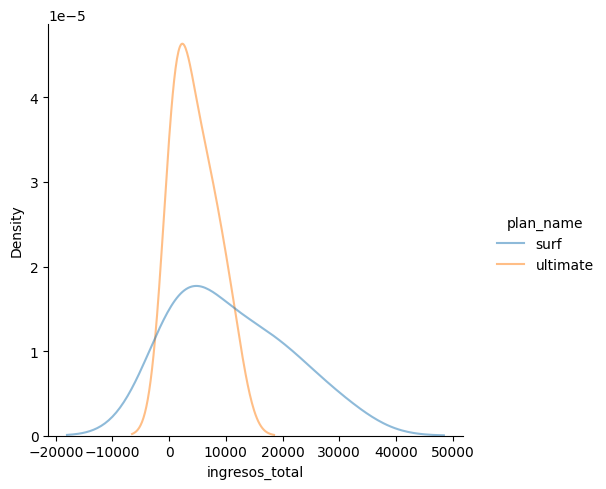

In [76]:
sns.displot(x='ingresos_total',data=ingreso_mes_plan, hue='plan_name', kind='kde', alpha =0.5)

- El ingreso promedio del plan ultimate fue mayor los primeros seis meses, los siguientes seis meses el plan Surf supero al plan ultimate. Lo que podria indicar el mayor uso del plan o mayor número de usuarios. 
- Los ingresos generados por el plan Ultimate, ascendieron a un poco mas de 11000 USD en un año, los 11 primeros meses apenas llegaron a casi 10000 USD. A compración del plan Surf que alcanzo los 10000 USD en 6 meses y luego continuo creciendo hasta alcanzar mas de 30000 USD. 
- La desviación estándar de los ingresos por mes del plan Surf es mayor que del plan Ultimate lo que indica que los ingresos en USD por mes del plan Surf se distribuye ampliamente en torno a la media aun mas que el plan Ultimate. Con el grafico podemos corroborar que los datos se distribuyen mas ampliamente en el caso de Surf que en el de Ultimate.
- La diferencia en las medias mensuales de ingresos sugiere que el plan Surf es más rentable que el plan Ultimate.
- Podemos observar que los ingresos mayores se dan por ingresos extras que por ingresos fijos.

## Probar las hipótesis estadísticas.

Hipótesis nula: El ingreso promedio de los usuarios del plan de llamada Ultimate es igual al ingreso promedio de los usuarios del plan de llamada Surf.

Hipótesis alternativa: El ingreso promedio de los usuarios del plan de llamada Ultimate es diferente al ingreso promedio de los usuarios del plan de llamada Surf.

In [77]:
# Prueba las hipótesis
ultimate1 = users_used_plan[users_used_plan['plan_name'] == 'ultimate']['ingresos_total']
surf1 = users_used_plan[users_used_plan['plan_name'] == 'surf']['ingresos_total']

alpha = 0.05

results = st.ttest_ind(ultimate1, surf1 ,equal_var = False)
print('p-value:', results.pvalue)

if results.pvalue<alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No rechazamos la hipótesis nula")

NameError: name 'st' is not defined

Para la prueba de hipotesis use hipótesis sobre la igualdad de las medias de dos poblaciones, porque quiero comparar las medias de dos poblaciones estadísticas diferentes. El valor de p (p-value) obtenido es menor que 0.05, y se considera que los resultados son estadísticamente significativos y se rechaza la hipótesis nula. El ingreso promedio de los usuarios del plan de llamada Ultimate es diferente al ingreso promedio de los usuarios del plan de llamada Surf.


Hipótesis nula: El ingreso promedio de los usuarios del área NY-NJ es igual al ingreso promedio de los usuarios de otras regiones.

Hipótesis alternativa: El ingreso promedio de los usuarios del área NY-NJ es diferente al ingreso promedio de los usuarios de otras regiones.

In [ ]:
# Prueba las hipótesis
ny_nj = users_used_plan[users_used_plan['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['ingresos_total']
otras_regiones= users_used_plan[users_used_plan['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['ingresos_total']

alpha = 0.05

results1 = st.ttest_ind(ny_nj, otras_regiones ,equal_var = False)
print('p-value:', results1.pvalue)

if results1.pvalue<alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No rechazamos la hipótesis nula")

p-value: 0.5552128941162344
No rechazamos la hipótesis nula




<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a><br>
Correcto. 
</div>


El valor de p (p-value) obtenido es mayor que 0.05, y se considera que los resultados no son estadísticamente significativos y no se rechaza la hipótesis nula. Este resultado implica que, según el análisis realizado, no se puede concluir que haya una diferencia significativa en los ingresos promedio entre los usuarios del área NY-NJ y los de otras regiones con un nivel de confianza del 95% (alpha=0.05). 

## Conclusión general

El data set se construyo a partir de 5 tablas que luego unirlas pudimos analizar los datos.
Se corrigieron errores de tipo de dato y se aumentaron columnas para facilitar el analisis.

Luego del analisis el plan Surf genera mas ingresos que el plan Ultimate, ya que su ingreso promedio es mayor. Además, la cantidad de minutos ultizados tambien supero al plan Ultimate, asi como los mensajes enviados y gb utilizados. Lo que se puede explicar con el aumento de  número de usuarios con el paso de los meses. Asi mismo, al calcular la varianza y desviacion estandar pudimos ver que los ingresos en USD por mes del plan Surf se distribuye ampliamente en torno a la media aun más que el plan Ultimate.

El ingreso promedio de los usuarios del plan de llamada Ultimate es igual al ingreso promedio de los usuarios del plan de llamada Surf.

El ingreso promedio de los usuarios del área NY-NJ es diferente al ingreso promedio de los usuarios de otras regiones.




<div class="alert alert-block alert-warning">
<b>Comentario del revisor #2</b> <a class=“tocSkip”></a>
Felicitaciones por tu trabajo hasta ahora! Parece que estás avanzando bien en tu proyecto.

- Es necesario que verifiquemos los valores que obtuvimos al utilizar un join del tipo "inner"para generar nuestra tabla de datos. 
- Recuerda que !024 Mb = 1Gb
    
Por lo demás, es un excelente proyecto. bastante bien detallado. 
    



Sigue adelante con tu proyecto y recuerda siempre revisar la calidad de tus datos y verificar tus resultados para obtener conclusiones precisas y confiables. ¡Mucho éxito! &#128077;
    
</div>
